In [345]:
 import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.set_printoptions(sci_mode=False)

In [346]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [347]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i, s in enumerate(chars)}
stoi['.']=0
itos= {s:i for i,s in stoi.items()}
itos


{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [348]:
block_size=4
X,Y=[],[]
for w in words:
    #print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context=context[1:]+[ix]
X=torch.tensor(X)
Y=torch.tensor(Y)

In [349]:
# build the dataset
block_size = 4 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xte, Yte = build_dataset(words[n1:])

torch.Size([182625, 4]) torch.Size([182625])
torch.Size([45521, 4]) torch.Size([45521])


In [350]:
X.shape, Y.shape

(torch.Size([228146, 4]), torch.Size([228146]))

In [351]:
C=torch.randn([27,2])
C

tensor([[ 0.2475,  0.1335],
        [ 0.2322, -1.9211],
        [ 0.6761, -0.4614],
        [ 0.9541, -1.9461],
        [ 0.8798, -2.4740],
        [ 0.2546,  0.9004],
        [ 0.9208, -0.0983],
        [-1.2922,  0.2006],
        [-0.6634,  0.2754],
        [-0.5075, -0.6248],
        [ 0.1930, -0.3980],
        [-2.3905, -1.3151],
        [-1.5816,  1.1688],
        [ 0.8059,  0.7023],
        [-0.3760, -1.5057],
        [-0.4726, -0.6730],
        [ 1.4971,  0.4773],
        [ 0.0235, -0.1164],
        [-0.8935,  0.1621],
        [ 0.4229, -0.9680],
        [-1.3376, -0.3957],
        [-0.4292,  1.4184],
        [-0.2876,  0.1453],
        [ 0.3900,  0.8927],
        [ 0.2217, -1.4359],
        [ 0.1207,  1.5421],
        [-2.0771,  2.8910]])

In [352]:
F.one_hot(torch.tensor(5),num_classes=27).float()@C

tensor([0.2546, 0.9004])

In [353]:
C[5]

tensor([0.2546, 0.9004])

In [354]:
emb=C[X]

In [355]:
W1=torch.randn([8,300])
b1=torch.randn(300)

In [356]:
h = torch.tanh(emb.view(-1, 8) @ W1 + b1)
h.shape

torch.Size([228146, 300])

In [357]:
W2=torch.randn([300,27])*0.01
b2=torch.randn(27)*0

In [358]:
logits=h@W2+b2
logits

tensor([[-0.1072, -0.0089, -0.0019,  ...,  0.0834,  0.2090,  0.0062],
        [-0.1883,  0.0064, -0.0558,  ...,  0.0727,  0.1558, -0.0754],
        [-0.1233,  0.0440, -0.0687,  ...,  0.0655,  0.2274, -0.1205],
        ...,
        [-0.0063, -0.0343, -0.2389,  ..., -0.1216, -0.0486, -0.3722],
        [-0.0405, -0.0527, -0.1603,  ...,  0.0693, -0.1387, -0.3227],
        [ 0.0337,  0.1011, -0.2439,  ..., -0.0332,  0.0299, -0.1838]])

In [359]:
logits.shape

torch.Size([228146, 27])

In [360]:
counts=logits.exp()

In [361]:
counts

tensor([[0.8983, 0.9911, 0.9981,  ..., 1.0869, 1.2325, 1.0062],
        [0.8283, 1.0064, 0.9457,  ..., 1.0754, 1.1685, 0.9274],
        [0.8840, 1.0449, 0.9336,  ..., 1.0677, 1.2553, 0.8865],
        ...,
        [0.9937, 0.9663, 0.7875,  ..., 0.8855, 0.9525, 0.6892],
        [0.9603, 0.9486, 0.8519,  ..., 1.0717, 0.8705, 0.7242],
        [1.0343, 1.1064, 0.7836,  ..., 0.9674, 1.0303, 0.8321]])

In [362]:
prob=counts/counts.sum(1,keepdims=True)

In [363]:
prob

tensor([[0.0332, 0.0366, 0.0369,  ..., 0.0402, 0.0456, 0.0372],
        [0.0311, 0.0378, 0.0355,  ..., 0.0403, 0.0438, 0.0348],
        [0.0335, 0.0396, 0.0354,  ..., 0.0405, 0.0476, 0.0336],
        ...,
        [0.0376, 0.0366, 0.0298,  ..., 0.0335, 0.0361, 0.0261],
        [0.0361, 0.0356, 0.0320,  ..., 0.0403, 0.0327, 0.0272],
        [0.0392, 0.0420, 0.0297,  ..., 0.0367, 0.0391, 0.0316]])

In [364]:
prob.shape

torch.Size([228146, 27])

In [366]:
loss=-(prob[torch.arange(182625),Ytr].log().mean())
loss

tensor(3.2914)

In [367]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 4]), torch.Size([182625]))

In [427]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((40, 200), generator=g)*(5/3)/(40**0.5)
b1 = torch.randn(200, generator=g)*0.01
W2 = torch.randn((200, 27), generator=g)*0.01
b2 = torch.randn(27, generator=g)*0
bngain=torch.ones((1,200))
bnbias=torch.zeros((1,200))
bnmean_running=torch.zeros((1,200))
bnstd_running=torch.ones((1,200))
parameters = [C, W1, b1, W2, b2, bngain, bnbias]

In [428]:
sum(p.nelement() for p in parameters)

14297

In [429]:
emb=C[Xtr]
h=torch.tanh((emb.view(-1,40)) @ W1+b1)
logits=h@W2+b2
counts=logits.exp()
prob=counts/counts.sum(1,keepdims=True)
loss=-prob[torch.arange(182625),Ytr].log().mean()
loss

tensor(3.2886)

In [430]:
F.cross_entropy(logits,Ytr)
#so we use cross entropy directly

tensor(3.2886)

In [431]:
for p in parameters:
    p.requires_grad=True

In [432]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [433]:
(torch.randn(1000)*0.2).std()

tensor(0.2016)

In [434]:
(5/3)/(30**0.5)

0.3042903097250923

tensor(0.0050) tensor(0.9992)
tensor(0.0025) tensor(1.0327)


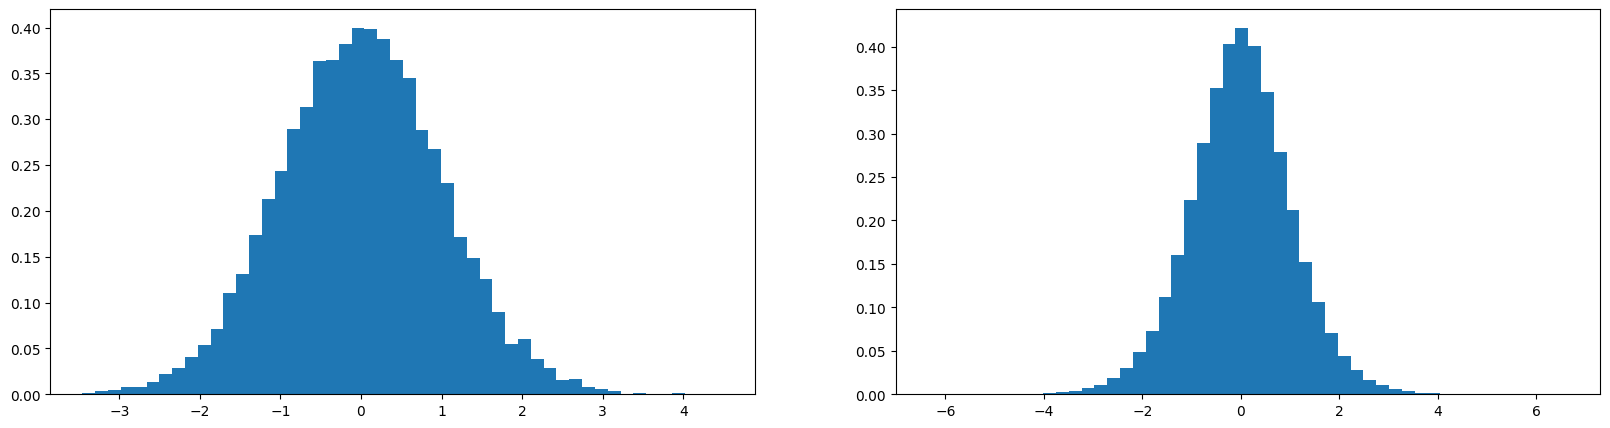

In [435]:
x = torch.randn(1000, 10)
w=torch.randn(10,200)/(10**0.5)
y=x@w
print(x.mean(),x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)

plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

plt.show()

In [437]:

for i in range(50000):
    ix=torch.randint(0,Xtr.shape[0],(32,))
    emb=C[Xtr[ix]]
    hpreact=emb.view(emb.shape[0], -1) @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True, unbiased=False)
    hpreact = bngain * ((hpreact - bnmeani) / (bnstdi + 1e-5)) + bnbias
    h = torch.tanh(hpreact)

    bnmean_running=0.999*bnmean_running+0.001*bnmeani
    bnstd_running=0.999*bnstd_running+0.001*bnstdi
    logits=h @ W2+b2
    loss=F.cross_entropy(logits,Ytr[ix])
    for p in parameters:
        p.grad=None
    loss.backward()
    lr=0.01
    for p in parameters:
        p.data+=-lr*p.grad
    #lri.append(lre[i])
    #lossi.append(loss.item())
print(loss.item())

2.430994749069214


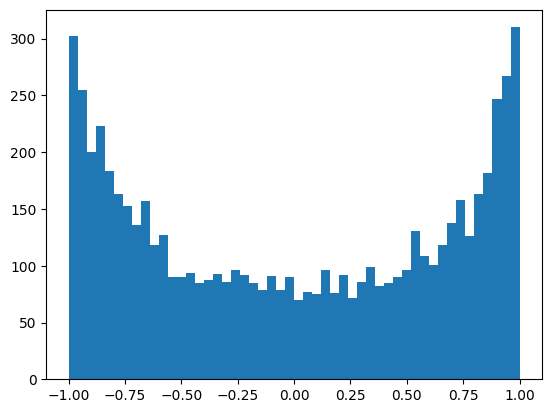

In [438]:
plt.hist(h.view(-1).tolist(),50);

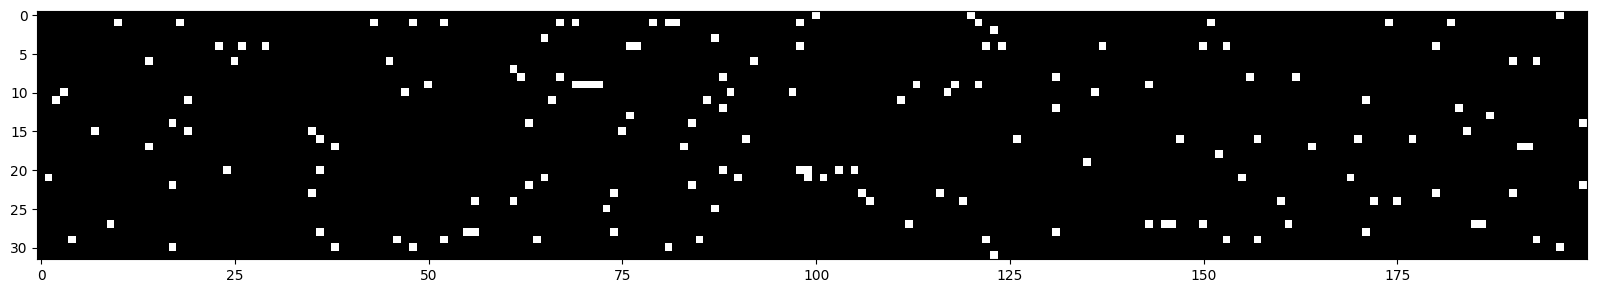

In [439]:
plt.figure(figsize=(20,10))
plt.imshow((h.abs()>0.99).cpu(), 
           cmap='gray',
           interpolation='nearest')

In [440]:
emb=C[Xte]
h=torch.tanh((emb.view(-1,40)) @ W1+b1)
logits=h @ W2+b2
loss=F.cross_entropy(logits,Yte)
loss.item()

2.7331671714782715

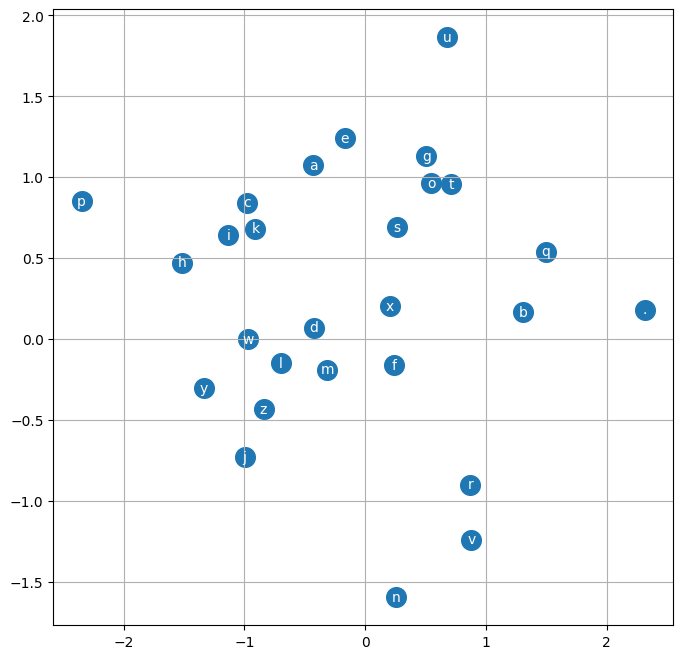

In [441]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [442]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(100):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])]

      hpreact = emb.view(emb.shape[0], -1) @ W1 + b1

      hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running + 1e-5)) + bnbias

      h = torch.tanh(hpreact)

      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
mayah.
seel.
ndhey.
lorethr.
jendrleg.
adelyn.
eliah.
miloen.
edellestanar.
kayzion.
karin.
sheb.
rishi.
jestin.
jowelle.
joberof.
ubreth.
aryyah.
fiek.
ylae.
misteyah.
halisa.
yansun.
zakel.
juren.
crevis.
jaoel.
pardin.
hoko.
obhi.
peila.
amuey.
conmeer.
mina.
iriel.
paysha.
ayortar.
shikee.
sila.
alis.
felvassin.
dameelakeyanna.
sxavin.
damarienna.
alim.
auda.
ived.
jhevorley.
jalena.
moostor.
cramiiah.
glon.
el.
jynnel.
ayap.
ryinogs.
makerzy.
shona.
jeresten.
mukenes.
amalyn.
maleyana.
bren.
candia.
nichiela.
moka.
oriannardika.
komaro.
samnen.
kenna.
mikel.
karues.
kaosa.
sain.
caic.
ciry.
ance.
adtel.
mayana.
lazaannee.
tegguthanna.
loigz.
kalyoraina.
ky.
tren.
ineshafrion.
soerrie.
mendad.
adya.
anlee.
zevane.
bariah.
athja.
veddo.
beejser.
eliana.
tane.
rose.
jexsi.
